<center> 2.Model Training for Gemstone Dataset </center>

#### Loading the necessary Libraries

In [20]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

<center> Read the Dataset </center>

In [5]:
df = pd.read_csv('./data/gemstone.csv')
df.head(2)

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387


**Droping id Column**

In [6]:
df = df.drop(labels=['id'],axis=1)

<center> Getting X and Y variables </center>

In [7]:
X = df.drop(columns=['price'],axis=1)
Y = df[['price']]

<center> Creating Data Transformation Pipeline </center>

**Creating Pipeline with Column Tranformer**

In [12]:
# Define which column should be ordinal-encoded and which shoulbe scaled
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

# Define the custom ranking for each oridinal variable
cut_categories = ['Fair','Good','Very Good','Premium','Ideal']
color_categories = ['D','E','F','G','H','I','J']
clarity_categories = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Numerical Pipeline
num_pipeline = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

# Categorical Pipeline
cat_pipeline = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('ordinal_encoder',OrdinalEncoder(categories=[cut_categories,color_categories,clarity_categories])),
        ('scaler',StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    [
        ('num_pipeline',num_pipeline,numerical_cols),
        ('cat_pipeline',cat_pipeline,categorical_cols)
    ]
)

<center> Train Test Split </center>

In [13]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X,Y,test_size=0.2,random_state=42)

<center> Transforming the data with pipeline created</center>

In [14]:
xtrain = pd.DataFrame(preprocessor.fit_transform(xtrain),columns=preprocessor.get_feature_names_out())
xtest = pd.DataFrame(preprocessor.transform(xtest),columns=preprocessor.get_feature_names_out())

In [15]:
preprocessor.get_feature_names_out()

array(['num_pipeline__carat', 'num_pipeline__depth',
       'num_pipeline__table', 'num_pipeline__x', 'num_pipeline__y',
       'num_pipeline__z', 'cat_pipeline__cut', 'cat_pipeline__color',
       'cat_pipeline__clarity'], dtype=object)

In [16]:
xtrain.head(2)

,num_pipeline__carat,num_pipeline__depth,num_pipeline__table,num_pipeline__x,num_pipeline__y,num_pipeline__z,cat_pipeline__cut,cat_pipeline__color,cat_pipeline__clarity
0,-1.016395,-0.204317,0.402608,-1.202472,-1.187395,-1.194148,-0.132842,-0.936018,-0.648950
1,0.882396,0.720758,-0.118536,0.985177,0.941823,1.036109,-0.132842,-0.320002,0.017052


In [17]:
xtest.head(2)

,num_pipeline__carat,num_pipeline__depth,num_pipeline__table,num_pipeline__x,num_pipeline__y,num_pipeline__z,cat_pipeline__cut,cat_pipeline__color,cat_pipeline__clarity
0,-0.628006,0.258221,-0.118536,-0.599293,-0.580341,-0.571414,0.872563,-1.552034,-0.648950
1,2.608569,-2.146973,-0.118536,2.128516,2.201232,1.962969,-1.138246,0.296015,-1.314953


<center> Model Training Baseline Models </center>

**Create an Evaluate Function to give all metrics after model Training**

In [18]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

**Training Various Models**

In [35]:
models = {
    "Linear Regressor": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-neighbours Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list=[]
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(xtrain, ytrain.values.flatten()) # Train model

    # Make prediction
    y_train_pred = model.predict(xtrain)
    y_test_pred = model.predict(xtest)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(ytrain,y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(ytest,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print('- Root Mean Squared Error: {:4f}'.format(model_train_rmse))
    print('- Mean Absolute Error: {:4f}'.format(model_train_mae))
    print('- R2 Score: {:.4f}'.format(model_train_r2))

    print('-------------------------------------------------')

    print('Model performance for Test set')
    print('- Root Mean Squared Error: {:.4f}'.format(model_test_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_test_r2))
    print('- R2 Score: {:.4f}'.format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regressor
Model performance for Training set
- Root Mean Squared Error: 1016.949028
- Mean Absolute Error: 677.165588
- R2 Score: 0.9366
-------------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 1006.6010
- Mean Absolute Error: 0.9373
- R2 Score: 0.9373


Lasso
Model performance for Training set
- Root Mean Squared Error: 1017.071754
- Mean Absolute Error: 678.314523
- R2 Score: 0.9366
-------------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 1006.8716
- Mean Absolute Error: 0.9373
- R2 Score: 0.9373


Ridge
Model performance for Training set
- Root Mean Squared Error: 1016.949085
- Mean Absolute Error: 677.192537
- R2 Score: 0.9366
-------------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 1006.6062
- Mean Absolute Error: 0.9373
- R2 Score: 0.9373


K-neighbours Regressor
Model performance for Training set
- Root Mean Squared Error

**Results**

In [36]:
df_results = pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)
df_results

,Model Name,R2_Score
7,CatBoosting Regressor,0.979186
6,XGBRegressor,0.978790
5,Random Forest Regressor,0.977204
3,K-neighbours Regressor,0.972114
4,Decision Tree,0.956816
0,Linear Regressor,0.937298
2,Ridge,0.937297
1,Lasso,0.937264
8,AdaBoost Regressor,0.856432


<center> Hyperparameter Tuning </center>

**Turning Catboost**

In [38]:
# Initializing Catboost
cbr = CatBoostRegressor(verbose=True)

# Creating the hyperparameter grid
param_dist = {'depth': [4,5,6,7,8,9,10],
              'learning_rate': [0.01,0.02,0.03,0.04],
              'iterations': [300,400,500,600]}

# Instantiate RandomSearchCV object
rscv = RandomizedSearchCV(cbr, param_dist, scoring='r2', cv=5, n_jobs=-1)

# Fit the model
rscv.fit(xtrain, ytrain.values.flatten())

# Print the tuned parameters and score
print(rscv.best_params_)
print(rscv.best_score_)

0:	learn: 3930.0461803	total: 77.3ms	remaining: 46.3s
1:	learn: 3824.3044631	total: 89.3ms	remaining: 26.7s
2:	learn: 3721.2455193	total: 98.8ms	remaining: 19.7s
3:	learn: 3620.7552167	total: 113ms	remaining: 16.9s
4:	learn: 3522.5294430	total: 121ms	remaining: 14.3s
5:	learn: 3427.7651051	total: 133ms	remaining: 13.1s
6:	learn: 3335.6147874	total: 141ms	remaining: 11.9s
7:	learn: 3245.6730768	total: 152ms	remaining: 11.3s
0:	learn: 3928.6239787	total: 73.4ms	remaining: 44s
8:	learn: 3160.0073565	total: 172ms	remaining: 11.3s
1:	learn: 3823.5792181	total: 101ms	remaining: 30.1s
9:	learn: 3076.3447046	total: 183ms	remaining: 10.8s
2:	learn: 3719.5662577	total: 114ms	remaining: 22.7s
0:	learn: 3928.4137986	total: 70.6ms	remaining: 42.3s
3:	learn: 3619.1051083	total: 129ms	remaining: 19.2s
10:	learn: 2995.2968007	total: 204ms	remaining: 10.9s
1:	learn: 3823.3654588	total: 89.7ms	remaining: 26.8s
0:	learn: 3926.2535858	total: 79.6ms	remaining: 47.7s
4:	learn: 3520.9225574	total: 146ms	rema

**Definition to print evaluated model results**

In [41]:
def print_evaluated_results(model,xtrain,y_train,xtest,ytest):
    ytrain_pred = model.predict(xtrain)
    ytest_pred = model.predict(xtest)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(ytrain, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(ytest, ytest_pred)

    # Pringing results
    print('Model performance for Training set')
    print('- Root Mean Squared Error: {:.4f}'.format(model_train_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_test_mae))
    print('- R2 Score: {:.4f}'.format(model_test_r2))

    print('-----------------------------------------------')

    print('Model Performance for Test set')
    print('- Root Mean Squared Error: {:.4f}'.format(model_test_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_test_mae))
    print('- R2 Score: {:.4f}'.format(model_test_r2))

In [42]:
# Selecting best model
best_cbr = rscv.best_estimator_

# Evaluate Train and Test dataset
print_evaluated_results(best_cbr,xtrain,ytrain,xtest,ytest)

Model performance for Training set
- Root Mean Squared Error: 1512.9617
- Mean Absolute Error: 294.4484
- R2 Score: 0.9795
-----------------------------------------------
Model Performance for Test set
- Root Mean Squared Error: 575.6947
- Mean Absolute Error: 294.4484
- R2 Score: 0.9795


**Tuning KNN**

In [43]:
from sklearn.model_selection import GridSearchCV
# Initialize knn
knn = KNeighborsRegressor()

# parameters
k_range = list(range(2, 31))
param_grid = dict(n_neighbors=k_range)

# Fitting the cvmodel
grid = GridSearchCV(knn, param_grid, cv=5, scoring='r2',n_jobs=-1)
grid.fit(xtrain, ytrain)

# Print the tuned parameters and score
print(grid.best_params_)
print(grid.best_score_)

{'n_neighbors': 16}
0.9736030364888257


In [44]:
# Selecting best model
best_knn = grid.best_estimator_

# Evaluate Train and Test dataset
print_evaluated_results(best_knn,xtrain,ytrain,xtest,ytest)

Model performance for Training set
- Root Mean Squared Error: 1512.9617
- Mean Absolute Error: 336.3513
- R2 Score: 0.9743
-----------------------------------------------
Model Performance for Test set
- Root Mean Squared Error: 643.8480
- Mean Absolute Error: 336.3513
- R2 Score: 0.9743


**Tuning XGBoost**

In [45]:
# Initializing xgboost
xgb = XGBRegressor()

# Parameters
params = {
 'learning_rate' : [0.05,0.10,0.15,0.20,0.25,0.30],
 'max_depth' : [ 3, 4, 5, 6, 8, 10, 12, 15],
 'min_child_weight' : [ 1, 3, 5, 7 ],
 'gamma': [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 'colsample_bytree' : [ 0.3, 0.4, 0.5 , 0.7 ],
 'n_estimators':[300,400,500,600]
}

rs_xgb=RandomizedSearchCV(xgb,param_distributions=params,scoring='r2',n_jobs=-1,cv=5)
rs_xgb.fit(xtrain, ytrain.values.flatten())

# Print the tuned parameters and score
print(rs_xgb.best_params_)
print(rs_xgb.best_score_)

/Users/ajwarck/Desktop/vs_code/ml-pro2-gem/venv-py311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.4, 'colsample_bytree': 0.7}
0.9792541265487671


In [46]:
# Selecting best xgb model
best_xgb = rs_xgb.best_estimator_

# Evaluate Train and Test dataset
print_evaluated_results(best_xgb,xtrain,ytrain,xtest,ytest)

Model performance for Training set
- Root Mean Squared Error: 1512.9617
- Mean Absolute Error: 292.1043
- R2 Score: 0.9792
-----------------------------------------------
Model Performance for Test set
- Root Mean Squared Error: 580.0399
- Mean Absolute Error: 292.1043
- R2 Score: 0.9792


<center> Voting Regressor </center>

In [47]:
from sklearn.ensemble import VotingRegressor

er = VotingRegressor([('cbr',best_cbr),('knn',best_knn),('xgb',XGBRegressor())], weights=[3,1,2])
er.fit(xtrain, ytrain.values.flatten())

print_evaluated_results(er,xtrain,ytrain,xtest,ytest)

0:	learn: 3886.0483432	total: 7.95ms	remaining: 4.76s
1:	learn: 3740.3384087	total: 13.8ms	remaining: 4.12s
2:	learn: 3599.7762097	total: 19.4ms	remaining: 3.87s
3:	learn: 3467.4247864	total: 25.1ms	remaining: 3.74s
4:	learn: 3339.3755347	total: 30.6ms	remaining: 3.64s
5:	learn: 3215.9777560	total: 35.9ms	remaining: 3.56s
6:	learn: 3097.4549792	total: 41.4ms	remaining: 3.51s
7:	learn: 2983.9637354	total: 46.9ms	remaining: 3.47s
8:	learn: 2874.6902032	total: 52.3ms	remaining: 3.43s
9:	learn: 2770.8140538	total: 57.9ms	remaining: 3.41s
10:	learn: 2671.0077611	total: 63.3ms	remaining: 3.39s
11:	learn: 2575.5736857	total: 69ms	remaining: 3.38s
12:	learn: 2483.0576232	total: 74.6ms	remaining: 3.37s
13:	learn: 2396.0343327	total: 80.2ms	remaining: 3.35s
14:	learn: 2311.4929287	total: 85.3ms	remaining: 3.33s
15:	learn: 2230.2676662	total: 91.1ms	remaining: 3.33s
16:	learn: 2152.4476734	total: 96.4ms	remaining: 3.31s
17:	learn: 2078.3030069	total: 102ms	remaining: 3.3s
18:	learn: 2006.3601337	

**Model Improved with Ensemble technique !**

<center> Catboost Model Feature Importances </center>

num_pipeline__carat      21.699064
num_pipeline__y          19.299357
cat_pipeline__clarity    16.666685
num_pipeline__z          14.601873
num_pipeline__x          14.390441
cat_pipeline__color      12.421344
cat_pipeline__cut         0.412599
num_pipeline__table       0.290624
num_pipeline__depth       0.218012
dtype: float64




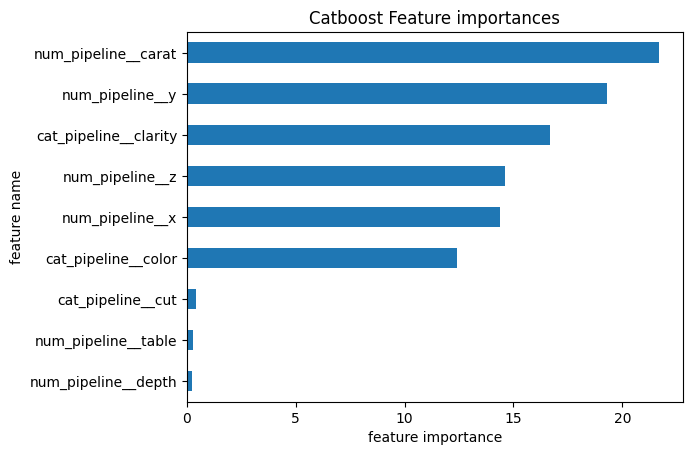

In [48]:
feature_imp = best_cbr.feature_importances_
feature_nm = best_cbr.feature_names_
imp_series = pd.Series(feature_imp)
imp_series.index = feature_nm
print(imp_series.sort_values(ascending=False))
print('\n')
imp_series.sort_values().plot(kind='barh',
                              xlabel='feature importance',
                              ylabel='feature name',
                              title='Catboost Feature importances')
plt.show()